# 01. FinTech Transaction Analysis
# Dataset: Financial Transaction Intelligence Dataset 2026
# Goal: Explore customer behavior, spending patterns and fraud signals

### Часть 1. Импорт + загрузка + первичный осмотр

Импорт библиотек

In [142]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Настройки отображения
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Библиотеки успешно загружены")

Библиотеки успешно загружены


Загрузка данных

In [143]:
# Пути к файлам
customers = pd.read_csv('../data/customers.csv')
merchants = pd.read_csv('../data/merchants.csv')
transactions = pd.read_csv('../data/transactions.csv')
cards = pd.read_csv('../data/cards.csv')
devices = pd.read_csv('../data/devices.csv')

print("Все таблицы успешно загружены")
print(f"customers:      {customers.shape}")
print(f"merchants:      {merchants.shape}")
print(f"transactions:   {transactions.shape}")
print(f"cards:          {cards.shape}")
print(f"devices:        {devices.shape}")

Все таблицы успешно загружены
customers:      (1000, 15)
merchants:      (200, 10)
transactions:   (10000, 29)
cards:          (1200, 8)
devices:        (1500, 8)


Первичный осмотр всех таблиц

In [144]:
def quick_look(df, name):
    print("="*60)
    print(f"Таблица: {name}")
    print("="*60)
    print(f"Размер: {df.shape[0]} строк × {df.shape[1]} столбцов")
    print("\nТипы данных:")
    print(df.dtypes)
    print("\nПропуски:")
    print(df.isnull().sum())
    print("\nПервые 3 строки:")
    display(df.head(3))
    print("\n")

quick_look(customers, "customers")
quick_look(merchants, "merchants")
quick_look(transactions, "transactions")
quick_look(cards, "cards")
quick_look(devices, "devices")

Таблица: customers
Размер: 1000 строк × 15 столбцов

Типы данных:
customer_id              str
age                    int64
gender                   str
country                  str
state                    str
city                     str
occupation               str
annual_income          int64
credit_score           int64
customer_since           str
account_type             str
risk_level               str
total_accounts         int64
avg_monthly_balance    int64
loan_status              str
dtype: object

Пропуски:
customer_id              0
age                      0
gender                   0
country                  0
state                    0
city                     0
occupation               0
annual_income            0
credit_score             0
customer_since           0
account_type             0
risk_level               0
total_accounts           0
avg_monthly_balance      0
loan_status            336
dtype: int64

Первые 3 строки:


,customer_id,age,gender,country,state,city,occupation,annual_income,credit_score,customer_since,account_type,risk_level,total_accounts,avg_monthly_balance,loan_status
0,C000001,58,Male,India,Maharashtra,Bengaluru,Teacher,885264,404,2022-08-03,Premium,Medium,1,314588,Active
1,C000002,20,Male,India,Karnataka,Bengaluru,Analyst,2825049,327,2021-04-17,Savings,Medium,5,224949,NaN
2,C000003,46,Other,UK,Tamil Nadu,London,Developer,969659,732,2018-10-25,Current,Low,3,58587,NaN




Таблица: merchants
Размер: 200 строк × 10 столбцов

Типы данных:
merchant_id              str
merchant_name            str
category                 str
city                     str
country                  str
years_in_business      int64
monthly_revenue        int64
risk_score           float64
fraud_history            str
online_store             str
dtype: object

Пропуски:
merchant_id          0
merchant_name        0
category             0
city                 0
country              0
years_in_business    0
monthly_revenue      0
risk_score           0
fraud_history        0
online_store         0
dtype: int64

Первые 3 строки:


,merchant_id,merchant_name,category,city,country,years_in_business,monthly_revenue,risk_score,fraud_history,online_store
0,M00001,Merchant_1,Travel,Mumbai,India,6,6102009,0.50,Yes,No
1,M00002,Merchant_2,Healthcare,Hyderabad,Germany,17,1153034,0.17,Yes,No
2,M00003,Merchant_3,Healthcare,San Francisco,Canada,11,7808824,0.72,Yes,No




Таблица: transactions
Размер: 10000 строк × 29 столбцов

Типы данных:
transaction_id                   str
customer_id                      str
merchant_id                      str
timestamp                        str
amount                       float64
currency                         str
payment_method                   str
transaction_type                 str
merchant_category                str
device_type                      str
operating_system                 str
browser                          str
IP_country                       str
geo_latitude                 float64
geo_longitude                float64
distance_from_home           float64
login_duration                 int64
transaction_hour               int64
day_of_week                      str
weekend                          str
international                    str
failed_login_attempts          int64
previous_transactions_24h      int64
average_spending_30d         float64
spending_change              float64
mer

,transaction_id,customer_id,merchant_id,timestamp,amount,currency,payment_method,transaction_type,merchant_category,device_type,operating_system,browser,IP_country,geo_latitude,geo_longitude,distance_from_home,login_duration,transaction_hour,day_of_week,weekend,international,failed_login_attempts,previous_transactions_24h,average_spending_30d,spending_change,merchant_risk,customer_risk,fraud_probability,is_fraud
0,T00000001,C000829,M00013,2025-06-23 00:03:00,56576.80,INR,Debit Card,Refund,Healthcare,POS,iOS,Chrome,India,-18.72,-111.00,18.82,340,0,Monday,No,No,5,20,8184.07,132.05,0.14,High,0.00,0
1,T00000002,C000221,M00079,2025-07-24 10:42:00,77231.61,INR,Debit Card,Refund,Travel,Desktop,Android,Safari,Germany,27.88,-162.25,41.41,523,10,Thursday,No,Yes,2,0,39784.88,-34.80,0.30,Low,0.32,0
2,T00000003,C000225,M00113,2025-02-22 10:06:00,74777.62,INR,UPI,Transfer,Travel,Desktop,macOS,Chrome,UK,-31.27,-81.88,440.38,358,10,Saturday,Yes,Yes,4,4,44678.56,-70.59,0.89,Medium,0.13,0




Таблица: cards
Размер: 1200 строк × 8 столбцов

Типы данных:
card_id                 str
customer_id             str
card_type               str
network                 str
card_limit            int64
utilization_rate    float64
reward_program          str
card_age              int64
dtype: object

Пропуски:
card_id             0
customer_id         0
card_type           0
network             0
card_limit          0
utilization_rate    0
reward_program      0
card_age            0
dtype: int64

Первые 3 строки:


,card_id,customer_id,card_type,network,card_limit,utilization_rate,reward_program,card_age
0,CARD000001,C000525,Credit,Mastercard,717671,0.75,No,7
1,CARD000002,C000023,Credit,RuPay,319335,0.72,Yes,7
2,CARD000003,C000989,Credit,Visa,648626,0.26,No,10




Таблица: devices
Размер: 1500 строк × 8 столбцов

Типы данных:
device_id            str
customer_id          str
device_type          str
manufacturer         str
operating_system     str
rooted               str
biometric_enabled    str
trusted_device       str
dtype: object

Пропуски:
device_id            0
customer_id          0
device_type          0
manufacturer         0
operating_system     0
rooted               0
biometric_enabled    0
trusted_device       0
dtype: int64

Первые 3 строки:


,device_id,customer_id,device_type,manufacturer,operating_system,rooted,biometric_enabled,trusted_device
0,D000001,C000081,Mobile,Apple,macOS,No,Yes,No
1,D000002,C000329,Mobile,Apple,iOS,Yes,No,No
2,D000003,C000184,Desktop,Samsung,Android,No,Yes,Yes


Базовая статистика по транзакциям (главная таблица)

In [145]:
print("Описательная статистика transactions:")
display(transactions.describe(include='all').T)

print("\nКоличество уникальных значений в ключевых столбцах:")
for col in transactions.columns:
    print(f"{col}: {transactions[col].nunique()}")

Описательная статистика transactions:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
transaction_id,10000,10000,T00000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,10000,1000,C000643,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN
merchant_id,10000,200,M00032,70,NaN,NaN,NaN,NaN,NaN,NaN,NaN
timestamp,10000,9935,2025-02-27 05:18:00,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amount,10000.00,NaN,NaN,NaN,49951.31,28779.44,24.65,25377.41,49741.32,74810.01,99996.03
currency,10000,1,INR,10000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
payment_method,10000,4,Credit Card,2580,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transaction_type,10000,3,Purchase,3386,NaN,NaN,NaN,NaN,NaN,NaN,NaN
merchant_category,10000,7,Grocery,1487,NaN,NaN,NaN,NaN,NaN,NaN,NaN
device_type,10000,3,Desktop,3367,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Количество уникальных значений в ключевых столбцах:
transaction_id: 10000
customer_id: 1000
merchant_id: 200
timestamp: 9935
amount: 9994
currency: 1
payment_method: 4
transaction_type: 3
merchant_category: 7
device_type: 3
operating_system: 4
browser: 4
IP_country: 5
geo_latitude: 10000
geo_longitude: 10000
distance_from_home: 9069
login_duration: 596
transaction_hour: 24
day_of_week: 7
weekend: 2
international: 2
failed_login_attempts: 6
previous_transactions_24h: 31
average_spending_30d: 9992
spending_change: 8165
merchant_risk: 101
customer_risk: 3
fraud_probability: 82
is_fraud: 2


### Часть 2. Очистка + базовый анализ

Преобразование timestamp и проверка пропусков

In [146]:
# Преобразуем timestamp в datetime
transactions['timestamp'] = pd.to_datetime(transactions['timestamp'])

# Создаём дополнительные временные признаки
transactions['date'] = transactions['timestamp'].dt.date
transactions['month'] = transactions['timestamp'].dt.month
transactions['hour'] = transactions['timestamp'].dt.hour

print("timestamp успешно преобразован")
print(f"Период данных: с {transactions['timestamp'].min()} по {transactions['timestamp'].max()}")
print("\nПропуски после преобразования:")
print(transactions.isnull().sum())

timestamp успешно преобразован
Период данных: с 2025-01-01 01:01:00 по 2026-05-01 22:54:00

Пропуски после преобразования:
transaction_id               0
customer_id                  0
merchant_id                  0
timestamp                    0
amount                       0
currency                     0
payment_method               0
transaction_type             0
merchant_category            0
device_type                  0
operating_system             0
browser                      0
IP_country                   0
geo_latitude                 0
geo_longitude                0
distance_from_home           0
login_duration               0
transaction_hour             0
day_of_week                  0
weekend                      0
international                0
failed_login_attempts        0
previous_transactions_24h    0
average_spending_30d         0
spending_change              0
merchant_risk                0
customer_risk                0
fraud_probability            0
is_fraud 

Проверка дубликатов и базовой целостности

In [147]:
print("Дубликаты по transaction_id:", transactions['transaction_id'].duplicated().sum())
print("Дубликаты полные:", transactions.duplicated().sum())

print("\nРаспределение is_fraud:")
print(transactions['is_fraud'].value_counts(normalize=True).mul(100).round(2))

print("\nКоличество уникальных клиентов:", transactions['customer_id'].nunique())
print("Количество уникальных мерчантов:", transactions['merchant_id'].nunique())

Дубликаты по transaction_id: 0
Дубликаты полные: 0

Распределение is_fraud:
is_fraud
0   96.94
1    3.06
Name: proportion, dtype: float64

Количество уникальных клиентов: 1000
Количество уникальных мерчантов: 200


Быстрый обзор ключевых числовых признаков

In [148]:
num_cols = ['amount', 'distance_from_home', 'login_duration', 
            'previous_transactions_24h', 'average_spending_30d', 
            'spending_change', 'merchant_risk', 'fraud_probability']

display(transactions[num_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
amount,10000.00,49951.31,28779.44,24.65,25377.41,49741.32,74810.01,99996.03
distance_from_home,10000.00,248.47,145.82,0.02,121.58,247.86,376.05,500.00
login_duration,10000.00,301.84,173.45,5.00,150.00,300.00,453.00,600.00
previous_transactions_24h,10000.00,15.02,8.91,0.00,7.00,15.00,23.00,30.00
average_spending_30d,10000.00,25295.04,14326.60,503.46,12956.58,25409.94,37793.75,49998.33
spending_change,10000.00,35.83,66.22,-79.98,-21.05,36.22,92.57,150.00
merchant_risk,10000.00,0.50,0.29,0.00,0.25,0.50,0.75,1.00
fraud_probability,10000.00,0.22,0.15,0.00,0.10,0.21,0.31,1.00


Первые важные инсайты

In [149]:
# 1. Средний чек
print("Средний чек:", round(transactions['amount'].mean(), 2))
print("Медианный чек:", round(transactions['amount'].median(), 2))

# 2. Доля мошеннических транзакций
fraud_rate = transactions['is_fraud'].mean() * 100
print(f"\nДоля мошеннических транзакций: {fraud_rate:.2f}%")

# 3. Средняя сумма мошеннических vs обычных
print("\nСредняя сумма обычных транзакций:", 
      round(transactions[transactions['is_fraud'] == 0]['amount'].mean(), 2))
print("Средняя сумма мошеннических транзакций:", 
      round(transactions[transactions['is_fraud'] == 1]['amount'].mean(), 2))

Средний чек: 49951.31
Медианный чек: 49741.32

Доля мошеннических транзакций: 3.06%

Средняя сумма обычных транзакций: 49943.39
Средняя сумма мошеннических транзакций: 50201.99


### Часть 3. Визуализации и ключевые инсайты

Распределение суммы транзакций

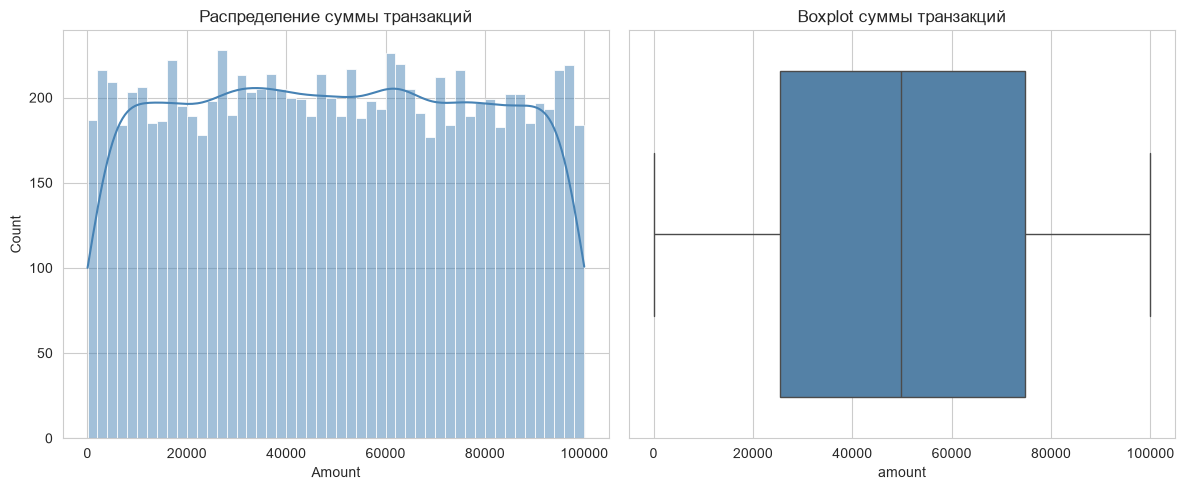

In [150]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(transactions['amount'], bins=50, kde=True, color='steelblue')
plt.title('Распределение суммы транзакций')
plt.xlabel('Amount')

plt.subplot(1, 2, 2)
sns.boxplot(x=transactions['amount'], color='steelblue')
plt.title('Boxplot суммы транзакций')

plt.tight_layout()
plt.savefig('../images/amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

Fraud vs обычные транзакции (сумма и риск)

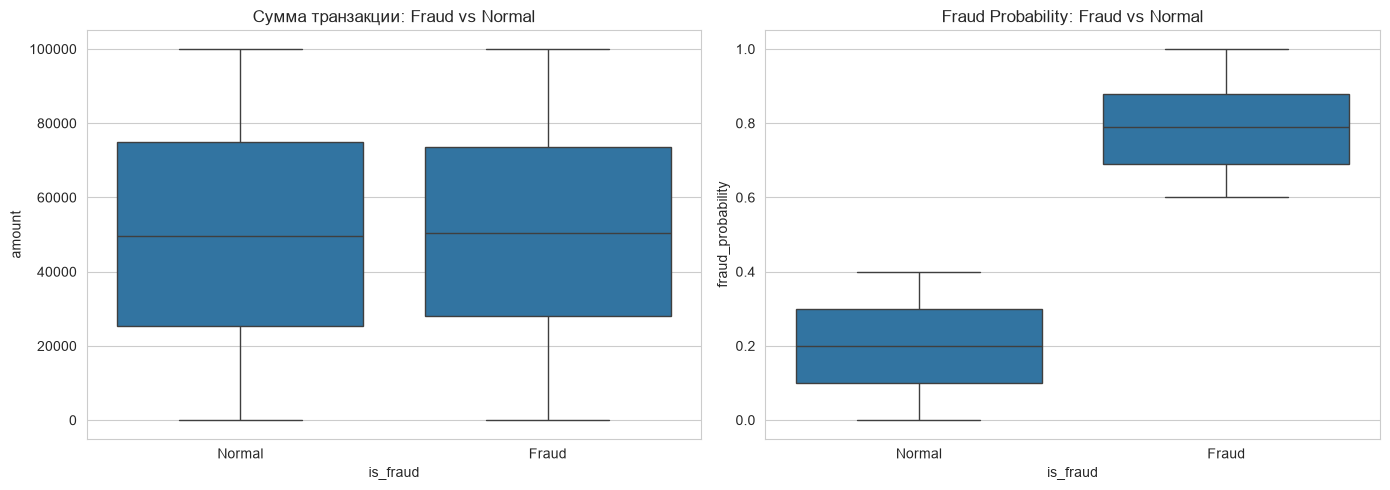

In [151]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=transactions, x='is_fraud', y='amount', ax=axes[0])
axes[0].set_title('Сумма транзакции: Fraud vs Normal')
axes[0].set_xticklabels(['Normal', 'Fraud'])

sns.boxplot(data=transactions, x='is_fraud', y='fraud_probability', ax=axes[1])
axes[1].set_title('Fraud Probability: Fraud vs Normal')
axes[1].set_xticklabels(['Normal', 'Fraud'])

plt.tight_layout()
plt.show()

Анализ по времени (час и день недели)

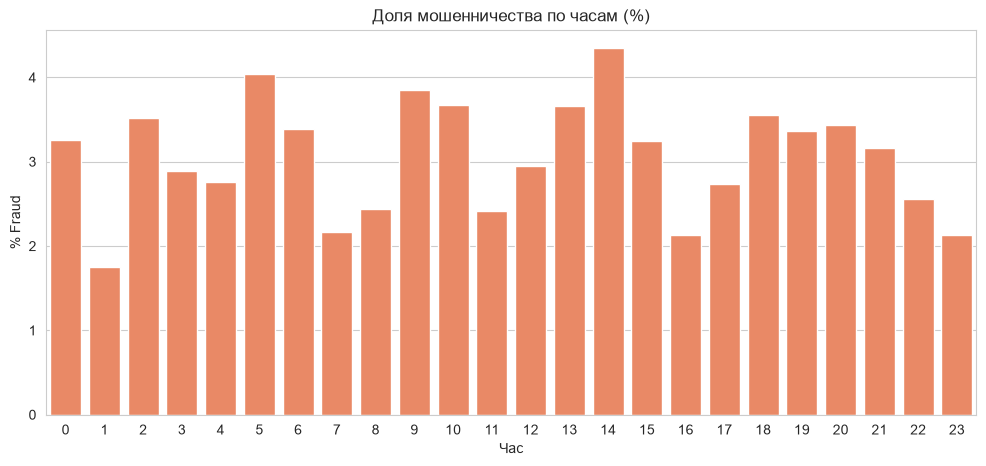

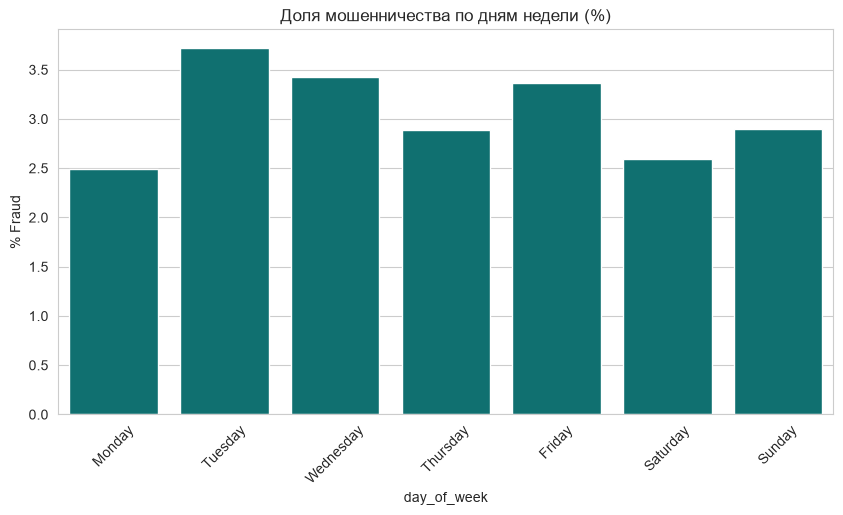

In [152]:
# По часу
hourly = transactions.groupby('transaction_hour')['is_fraud'].mean() * 100

plt.figure(figsize=(12, 5))
sns.barplot(x=hourly.index, y=hourly.values, color='coral')
plt.title('Доля мошенничества по часам (%)')
plt.xlabel('Час')
plt.ylabel('% Fraud')
plt.savefig('../images/fraud_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()

# По дню недели
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow = transactions.groupby('day_of_week')['is_fraud'].mean().reindex(dow_order) * 100

plt.figure(figsize=(10, 5))
sns.barplot(x=dow.index, y=dow.values, color='teal')
plt.title('Доля мошенничества по дням недели (%)')
plt.xticks(rotation=45)
plt.ylabel('% Fraud')
plt.show()

Категории мерчантов и fraud

In [153]:
category_fraud = (transactions.groupby('merchant_category')['is_fraud']
                  .agg(['count', 'mean'])
                  .rename(columns={'mean': 'fraud_rate'})
                  .sort_values('fraud_rate', ascending=False))

category_fraud['fraud_rate'] = (category_fraud['fraud_rate'] * 100).round(2)

print("Топ категорий по доле мошенничества:")
display(category_fraud.head(10))

Топ категорий по доле мошенничества:


,count,fraud_rate
merchant_category,,
Entertainment,1451,3.79
Retail,1413,3.54
Food,1378,3.19
Travel,1425,2.88
Grocery,1487,2.82
Healthcare,1447,2.76
Electronics,1399,2.43


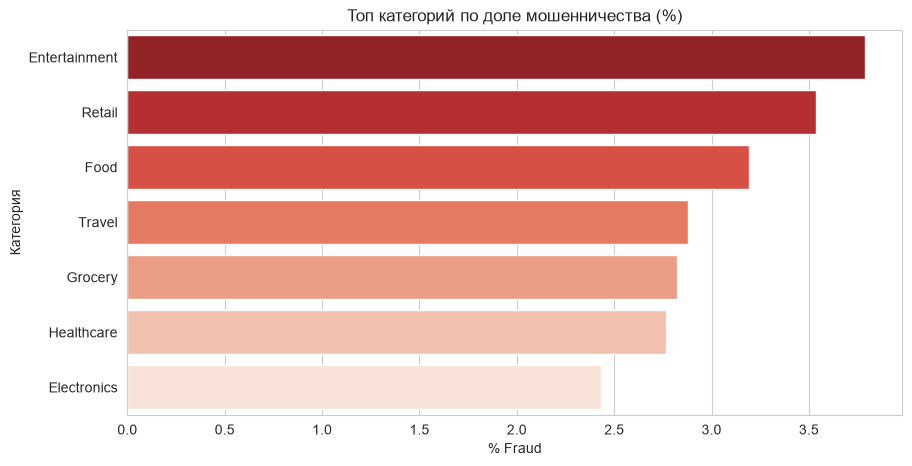

In [154]:
# Топ категорий по доле мошенничества
category_fraud = (transactions.groupby('merchant_category')['is_fraud']
                  .mean()
                  .sort_values(ascending=False)
                  .head(8) * 100)

plt.figure(figsize=(10, 5))
sns.barplot(x=category_fraud.values, y=category_fraud.index, palette='Reds_r')
plt.title('Топ категорий по доле мошенничества (%)')
plt.xlabel('% Fraud')
plt.ylabel('Категория')

plt.savefig('../images/fraud_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

Важные числовые признаки и fraud

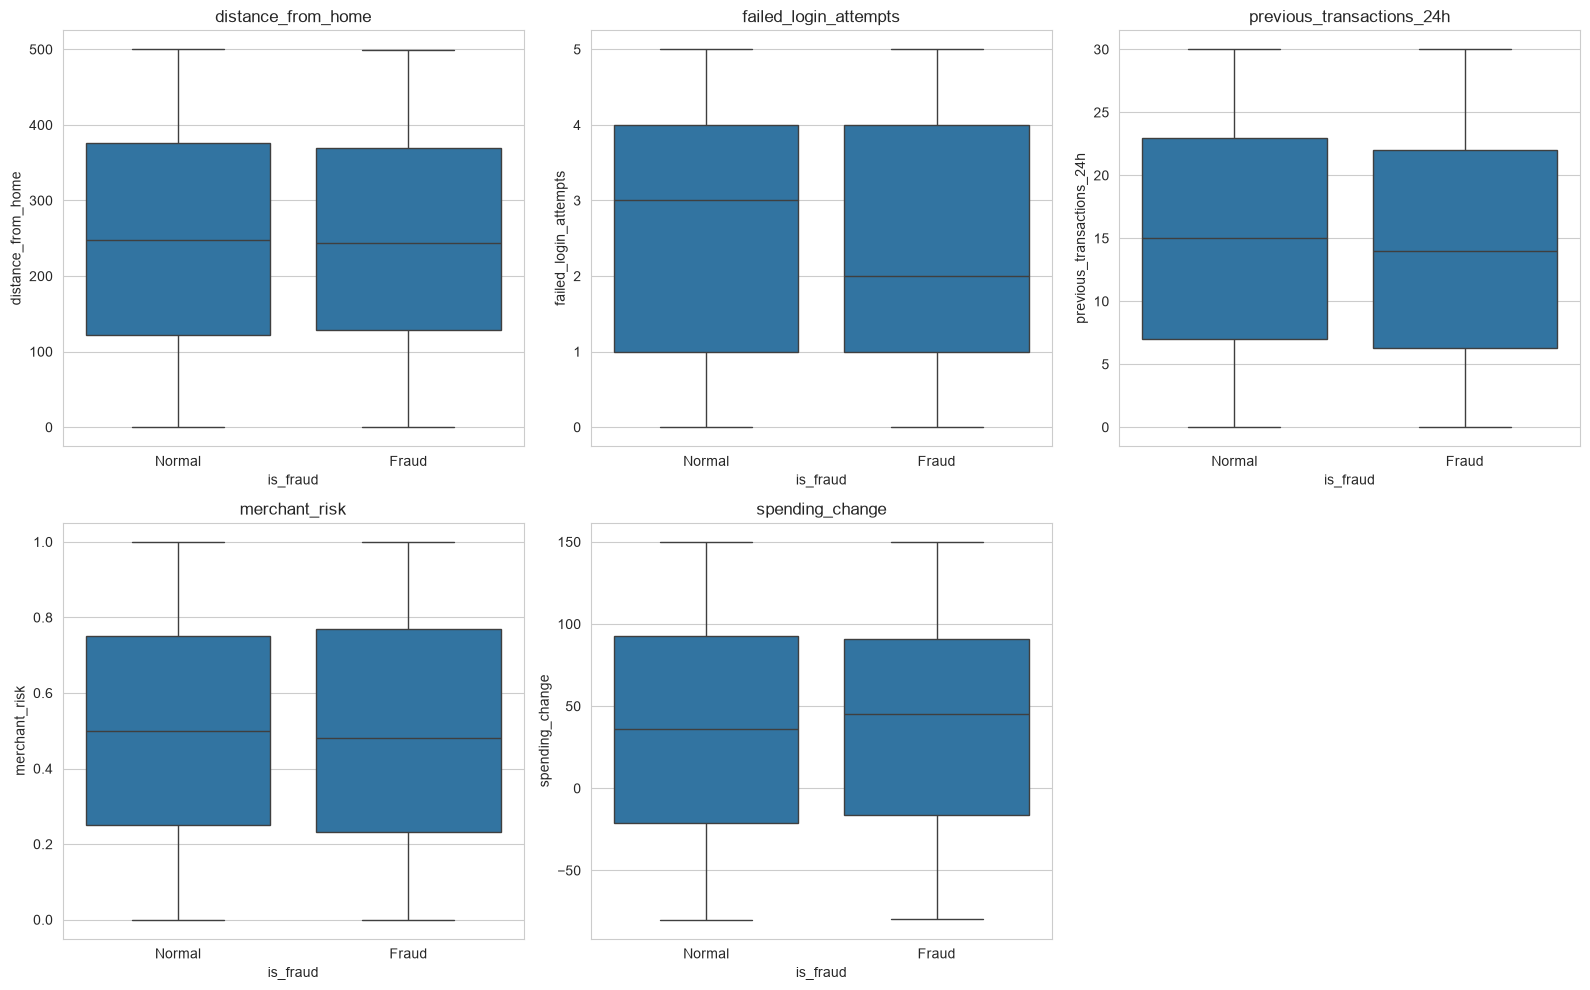

In [155]:
risk_cols = ['distance_from_home', 'failed_login_attempts', 
             'previous_transactions_24h', 'merchant_risk', 'spending_change']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(risk_cols):
    sns.boxplot(data=transactions, x='is_fraud', y=col, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xticklabels(['Normal', 'Fraud'])

# Убираем пустой subplot
fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

### Ключевые инсайты

1. **Доля мошенничества** составляет 3.06% — реалистичный уровень для финтех-продуктов.

2. **Средний чек** почти не отличается между обычными и мошенническими транзакциями 
   (≈ 49 943 vs 50 202). Мошенники не выделяются крупными суммами.

3. **Временные паттерны**:
   - Повышенный риск в 5:00, 9:00 и 14:00
   - По дням недели выше во вторник, среду и пятницу

4. **Категории с наибольшим риском**:
   - Entertainment (3.79%)
   - Retail (3.54%)
   - Food (3.19%)

5. Отдельные признаки (`distance_from_home`, `failed_login_attempts`, `merchant_risk` и др.) 
   по отдельности слабо разделяют fraud и normal. Это говорит о том, что 
   для детекции нужна комбинация признаков + поведенческие паттерны.

### Рекомендации

1. Усилить мониторинг транзакций в категории **Entertainment** и **Retail**.
2. Добавить дополнительные проверки в часы повышенного риска (5:00, 9:00, 14:00).
3. Обратить внимание на транзакции с необычным `spending_change` и низкой активностью 
   за последние 24 часа.
4. Рассмотреть внедрение правил, основанных на комбинации признаков, 
   а не на одном показателе.
5. Для дальнейшего улучшения модели — собрать больше данных по поведению 
   устройств и геолокации.